In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 20
SPLIT = 0.2  # 20% for validation

In [ ]:
X, Y = [], []

for i, cat in enumerate(classes):
    images = glob(f'{path}/{cat}/*.JPG')  # Make sure images have .JPG extension

    for img_path in images:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Convert BGR to RGB
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

# One-hot encoding for categorical crossentropy
Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

# Split into training and validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_cat,
    test_size=SPLIT,
    random_state=42,
    stratify=Y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 242
Validation samples: 61


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
], name="augmentation")

In [ ]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

# Preprocessing for each branch
eff_input = eff_preprocess(x)
dense_input = dense_preprocess(x)

# Branch A: EfficientNetB0
base_eff = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=eff_input)
base_eff.trainable = False  # Freeze pretrained weights
eff_feat = layers.GlobalAveragePooling2D()(base_eff.output)

# Branch B: DenseNet121
base_dense = DenseNet121(include_top=False, weights="imagenet", input_tensor=dense_input)
base_dense.trainable = False  # Freeze pretrained weights
dense_feat = layers.GlobalAveragePooling2D()(base_dense.output)

# Combine features
combined = layers.Concatenate()([eff_feat, dense_feat])

# Classification Head
x = layers.Dense(512, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(len(classes), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 256, 256,  │          0 │ augmentation[0][… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r

 Total params: 12,402,149 (47.31 MB)

 Trainable params: 1,313,538 (5.01 MB)

 Non-trainable params: 11,088,611 (42.30 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 146s 15s/step - accuracy: 0.5329 - loss: 1.0270 - val_accuracy: 0.7377 - val_loss: 0.6224 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 138s 17s/step - accuracy: 0.5090 - loss: 1.2787 - val_accuracy: 0.6230 - val_loss: 0.6818 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 127s 16s/step - accuracy: 0.5432 - loss: 0.9953 - val_accuracy: 0.5082 - val_loss: 0.7246 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4916 - loss: 1.2280 
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
8/8 ━━━━━━━━━━━━━━━━━━━━ 141s 16s/step - accuracy: 0.4935 - loss: 1.2179 - val_accuracy: 0.4754 - val_loss: 0.7084 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 126s 16s/step - accuracy: 0.5107 - loss: 1.0133 - val_accuracy: 0.4918 - val_loss: 0.7079 - learning_rate: 2.0000e-05
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 115s 15s/step - accuracy: 0.5612 - loss: 0.91

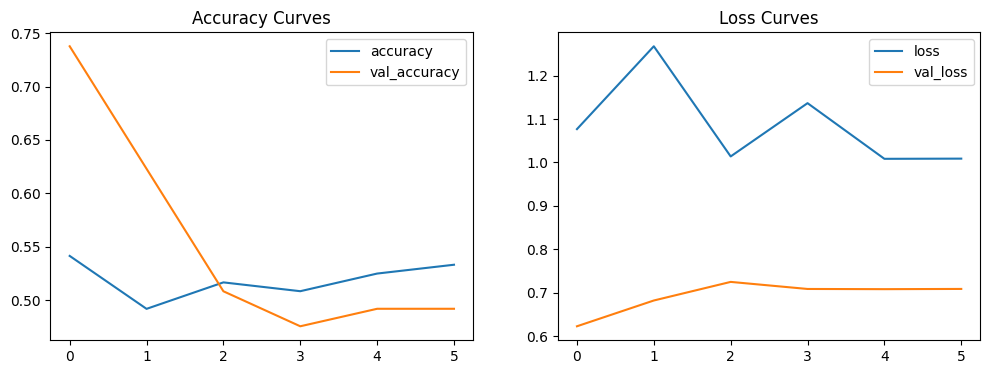

In [ ]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')
history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 17s/step
              precision    recall  f1-score   support

    Non Iris       0.00      0.00      0.00         0
        Iris       1.00      0.74      0.85        61

    accuracy                           0.74        61
   macro avg       0.50      0.37      0.42        61
weighted avg       1.00      0.74      0.85        61

Validation Accuracy: 73.77%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


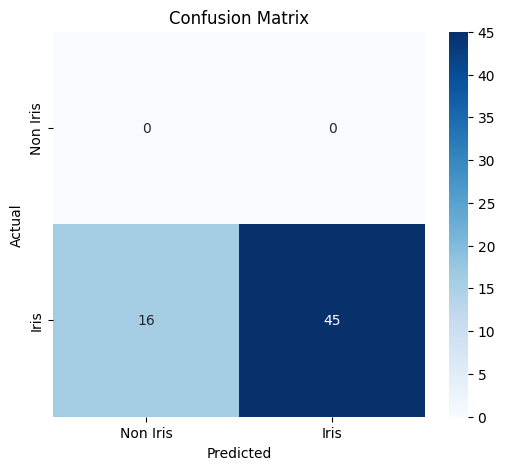

In [ ]:
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

# Classification report
report = classification_report(Y_true, Y_pred_classes, target_names=classes)
print(report)

# Calculate accuracy in %
accuracy = np.sum(Y_pred_classes == Y_true) / len(Y_true) * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = np.sum(Y_pred_classes == Y_true) / len(Y_true) * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 73.77%


Saving 0 (193).jpg to 0 (193).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Prediction: Iris with confidence 54.25%


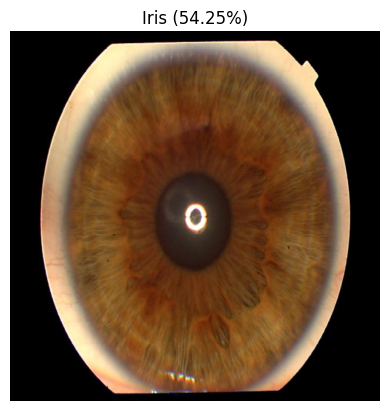

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload an image from your computer
uploaded = files.upload()

for fname in uploaded.keys():
    img_path = fname
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_resized, axis=0)  # Model expects batch dimension

    # Predict
    pred = model.predict(img_array)
    pred_class = np.argmax(pred, axis=1)[0]
    confidence = pred[0][pred_class] * 100  # probability %

    print(f"Prediction: {classes[pred_class]} with confidence {confidence:.2f}%")

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{classes[pred_class]} ({confidence:.2f}%)")
    plt.show()